# 📈 ESG Regression Modeling
**Objective:** Predict Profit Margin from ESG and environmental metrics.

**Features:** ESG_Overall, CarbonEmissions, WaterUsage, EnergyConsumption

**Models:** Linear, Polynomial, Ridge, Lasso, ElasticNet, Random Forest, Gradient Boosting, XGBoost

---

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib, os

## 2. Load & Inspect Data

In [2]:
df = pd.read_csv('data/esg_processed.csv', index_col=0)
df.head()

,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption,ESG_Category
CompanyID,,,,,,,,,,,,,,,,
1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7,Good
1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4,Good
1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9,Good
1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2,Good
1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8,Good


In [3]:
df.dtypes

CompanyName           object
Industry              object
Region                object
Year                   int64
Revenue              float64
ProfitMargin         float64
MarketCap            float64
GrowthRate           float64
ESG_Overall          float64
ESG_Environmental    float64
ESG_Social           float64
ESG_Governance       float64
CarbonEmissions      float64
WaterUsage           float64
EnergyConsumption    float64
ESG_Category          object
dtype: object

In [4]:
df.isnull().sum()

CompanyName             0
Industry                0
Region                  0
Year                    0
Revenue                 0
ProfitMargin            0
MarketCap               0
GrowthRate           1000
ESG_Overall             0
ESG_Environmental       0
ESG_Social              0
ESG_Governance          0
CarbonEmissions         0
WaterUsage              0
EnergyConsumption       0
ESG_Category            0
dtype: int64

## 3. Exploratory Analysis of Target & Features

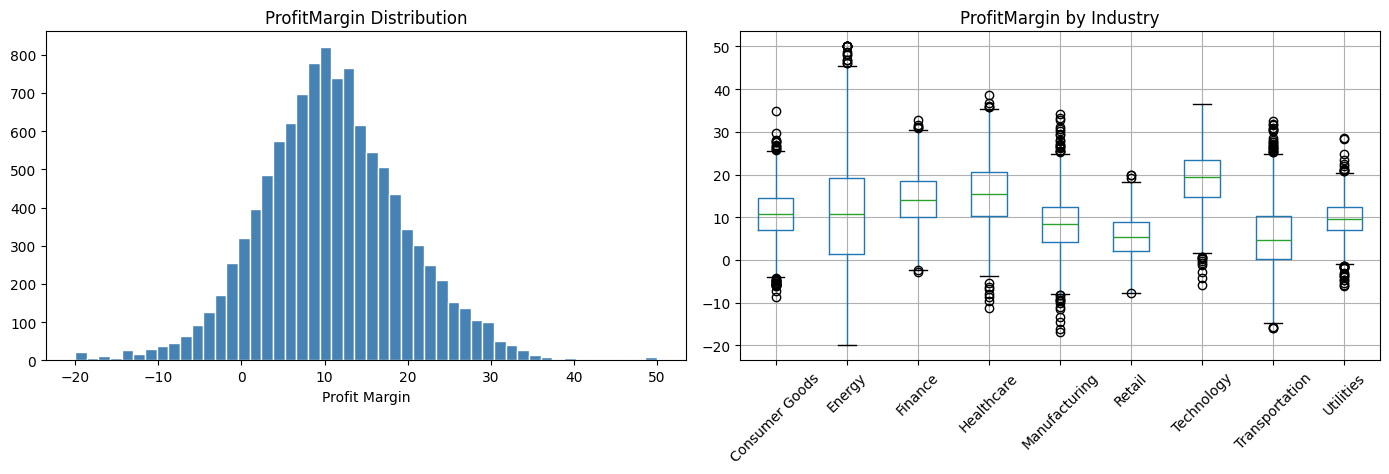

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['ProfitMargin'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('ProfitMargin Distribution')
axes[0].set_xlabel('Profit Margin')

# Boxplot by Industry
df.boxplot(column='ProfitMargin', by='Industry', ax=axes[1], rot=45)
axes[1].set_title('ProfitMargin by Industry')
axes[1].set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

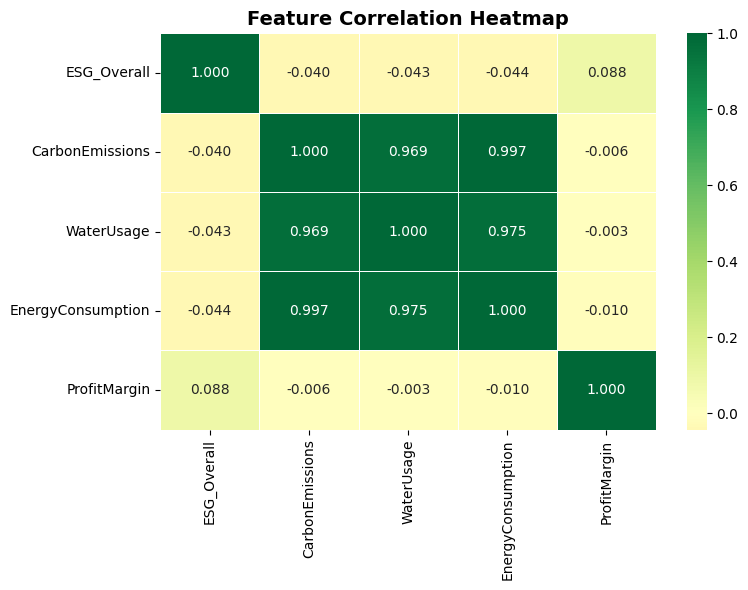

In [7]:
FEATURES = ['ESG_Overall', 'CarbonEmissions', 'WaterUsage', 'EnergyConsumption']
TARGET = 'ProfitMargin'

corr_data = df[FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_data, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
 linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Preprocessing & Train-Test Split

In [8]:
df_model = df[FEATURES + [TARGET]].dropna()
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

Train: (8800, 4) | Test: (2200, 4)


## 5. Model Training & Comparison

In [9]:
models = {
 'Linear Regression': LinearRegression(),
 'Polynomial (deg=2)': Pipeline([
 ('poly', PolynomialFeatures(degree=2, include_bias=False)),
 ('lr', LinearRegression())
 ]),
 'Ridge': Ridge(alpha=1.0),
 'Lasso': Lasso(alpha=0.01),
 'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),
 'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
 'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
 'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = []
trained_models = {}

for name, model in models.items():
 model.fit(X_train_scaled, y_train)
 y_pred = model.predict(X_test_scaled)
 rmse = np.sqrt(mean_squared_error(y_test, y_pred))
 mae = mean_absolute_error(y_test, y_pred)
 r2 = r2_score(y_test, y_pred)
 results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
 trained_models[name] = model
 print(f'{name:25s} | RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f}')

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print('\n=== Ranked by R² ===')
results_df

Linear Regression         | RMSE=8.9282 | MAE=6.8326 | R²=-0.0013
Polynomial (deg=2)        | RMSE=8.7862 | MAE=6.7324 | R²=0.0303
Ridge                     | RMSE=8.9272 | MAE=6.8319 | R²=-0.0010
Lasso                     | RMSE=8.9201 | MAE=6.8302 | R²=0.0005
ElasticNet                | RMSE=8.9192 | MAE=6.8324 | R²=0.0008
Random Forest             | RMSE=7.5917 | MAE=5.4375 | R²=0.2761
Gradient Boosting         | RMSE=8.0841 | MAE=6.1180 | R²=0.1791
XGBoost                   | RMSE=7.6627 | MAE=5.5682 | R²=0.2625

=== Ranked by R² ===


,Model,RMSE,MAE,R2
5,Random Forest,7.591661,5.437528,0.276072
7,XGBoost,7.662695,5.568219,0.262462
6,Gradient Boosting,8.084089,6.117981,0.179113
1,Polynomial (deg=2),8.786185,6.732389,0.030334
4,ElasticNet,8.919192,6.832350,0.000754
3,Lasso,8.920128,6.830240,0.000544
2,Ridge,8.927186,6.831875,-0.001038
0,Linear Regression,8.928152,6.832643,-0.001255


In [10]:
fig = make_subplots(rows=1, cols=3, subplot_titles=['R² Score', 'RMSE', 'MAE'])

for i, metric in enumerate(['R2', 'RMSE', 'MAE'], 1):
 sorted_df = results_df.sort_values(metric, ascending=(metric != 'R2'))
 fig.add_trace(go.Bar(x=sorted_df['Model'], y=sorted_df[metric], name=metric,
 marker_color=['#2ecc71' if j == 0 else '#95a5a6' for j in range(len(sorted_df))]), row=1, col=i)

fig.update_layout(title='Regression Model Comparison', showlegend=False, height=450)
fig.show()

## 6. Hyperparameter Tuning (Random Forest)

In [11]:
param_grid = {
 'n_estimators': [50, 100, 150],
 'max_depth': [ 3, 5],
 'min_samples_split': [2, 5],
 'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f'Best Params: {grid_search.best_params_}')
print(f'Best CV R²: {grid_search.best_score_:.4f}')
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R²: 0.1562


## 7. Final Model Evaluation

In [12]:
y_pred_best = best_model.predict(X_test_scaled)

print('=== Tuned Random Forest Performance ===')
print(f'R² Score : {r2_score(y_test, y_pred_best):.4f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}')
print(f'MAE : {mean_absolute_error(y_test, y_pred_best):.4f}')

=== Tuned Random Forest Performance ===
R² Score : 0.1475
RMSE : 8.2383
MAE : 6.2218


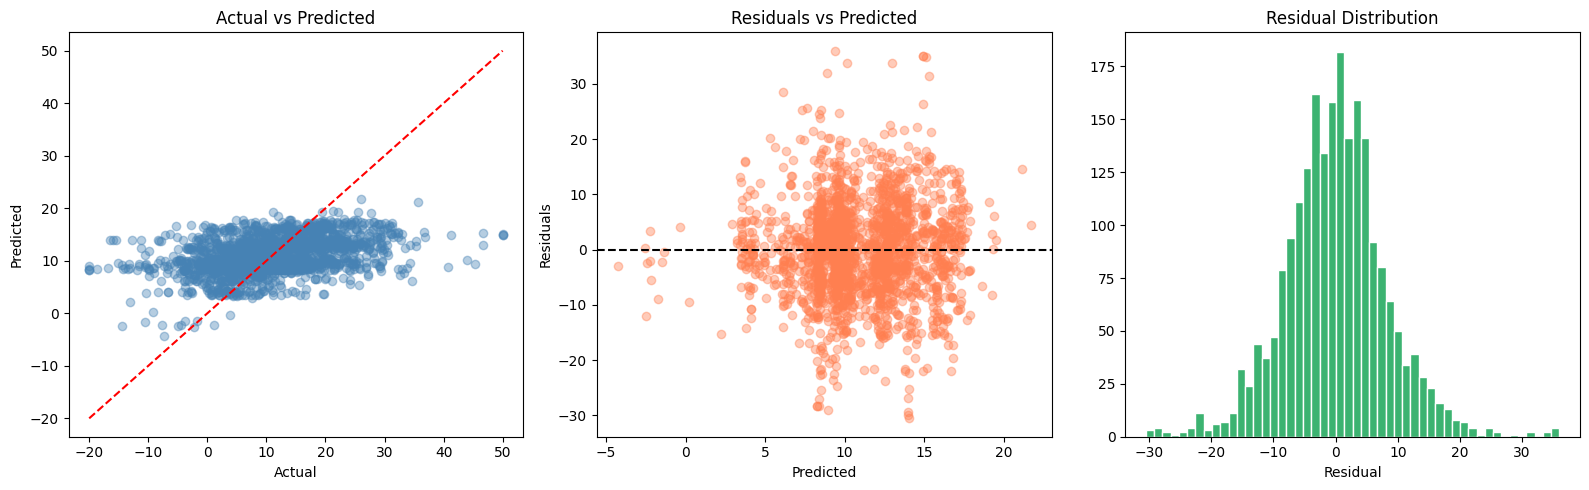

In [14]:
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Actual vs Predicted')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')

# Residuals vs Predicted
axes[1].scatter(y_pred_best, residuals, alpha=0.4, color='coral')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residuals')

# Residual Distribution
axes[2].hist(residuals, bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Residual Distribution')
axes[2].set_xlabel('Residual')

plt.tight_layout()
plt.show()

In [15]:
feat_imp = pd.DataFrame({
 'Feature': FEATURES,
 'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig = px.bar(feat_imp, x='Feature', y='Importance',
 color='Importance', color_continuous_scale='Blues',
 title='Feature Importance - XGBoost',
 text='Importance')
fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.show()

## 8. Save Model & Results

In [16]:
joblib.dump(best_model, 'models/best_regression_model.pkl')
joblib.dump(scaler, 'models/regression_scaler.pkl')

['models/regression_scaler.pkl']